# imports & setup

In [ ]:
from pathlib import Path
from typing import Any, Literal
import itertools

from jaxtyping import Float
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.colors
from tqdm import tqdm

# scipy
from sklearn.manifold import TSNE, Isomap
from sklearn.decomposition import PCA
import sklearn.base
import umap

# muutils
import muutils.tensor_info
from muutils.dbg import dbg_tensor

# attention-motifs
from attention_motifs.features.analysis import parse_cls, DistanceTensorResult
from attention_motifs.features.head_analysis import filter_umap_warns
from attention_motifs.attnpedia.attnpedia import AttentionPedia

In [ ]:
# magic autoreload
%load_ext autoreload
%autoreload 2

# numbers of rows to display
pl.Config.set_tbl_rows(10)
# colored muutils tensor info
muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True
# base path
PATH_BASE: Path = Path("../data/")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# load dists

In [ ]:
# load head distances
HEAD_DISTS: DistanceTensorResult = DistanceTensorResult.read(
	PATH_BASE / "features" / "head_dists.zanj"
)
dbg_tensor(HEAD_DISTS.distances)
dbg_tensor(HEAD_DISTS.mean_dists)
# load attentionpedia
ATTENTIONPEDIA: AttentionPedia = AttentionPedia()

[ <ipykernel>:4 ] HEAD_DISTS.distances: μ=10.51 σ=4.48 x̃=9.62 R=[0.00,34.04] ℙ=| █▅▁   | shape=(1520,1520) dtype=float64
[ <ipykernel>:5 ] HEAD_DISTS.mean_dists: μ=10.51 σ=4.48 x̃=9.62 R=[0.00,34.04] ℙ=| █▅▁   | shape=(1520,1520) dtype=float64


array([[ 0.        ,  8.69202432,  9.54040428, ..., 12.25940865,
        12.16375817, 12.23178058],
       [ 8.69202432,  0.        ,  9.8659314 , ...,  9.98180279,
         9.99545272,  9.95879912],
       [ 9.54040428,  9.8659314 ,  0.        , ...,  8.9271944 ,
         8.64037894,  8.91942945],
       ...,
       [12.25940865,  9.98180279,  8.9271944 , ...,  0.        ,
         1.75838832,  1.64093945],
       [12.16375817,  9.99545272,  8.64037894, ...,  1.75838832,
         0.        ,  1.69310037],
       [12.23178058,  9.95879912,  8.91942945, ...,  1.64093945,
         1.69310037,  0.        ]])

# head projection & clustering

In [ ]:
def create_head_embedding_df(
	head_dists: DistanceTensorResult,
	attnpedia: AttentionPedia | None = None,
	embedding_method: Literal["isomap", "umap", "tsne", "pca"] = "isomap",
	n_components: int = 3,
	n_neighbors: int = 15,
	reducer_kwargs: dict[str, Any] | None = None,
	save_path: Path | None = None,
) -> pl.DataFrame:
	"""
	Create a polars DataFrame from head distance data, with embeddings and type information.

	# Parameters:
	 - `head_dists : DistanceTensorResult`
	    The head distances object containing cls_values and distances
	 - `attnpedia : Optional[AttentionPedia]`
	    AttentionPedia object for head type lookups, if None a new one will be created
	 - `embedding_method : Literal["isomap", "umap", "tsne", "pca"]`
	    Method to use for dimensionality reduction
	 - `n_components : int`
	    Number of dimensions for the embedding (default: 3)
	 - `n_neighbors : int`
	    Number of neighbors to consider for manifold methods (default: 15)
	 - `random_state : int`
	    Random seed for reproducibility (default: 42)

	# Returns:
	 - `pl.DataFrame`
	    A dataframe with one row per head, containing:
	    - cls string
	    - model, layer, head extracted from cls
	    - embedding dimensions (embed.0, embed.1, etc.)
	    - head types (primary_type and all_types)
	"""
	# kwargs
	reducer_kwargs_: dict[str, Any] = reducer_kwargs or {}
	# Create AttentionPedia if not provided
	if attnpedia is None:
		attnpedia = AttentionPedia()

	# Get distance matrix
	distance_matrix: Float[np.ndarray, "n_heads n_heads"] = head_dists.mean_dists

	# Create embedding based on specified method
	reducer: sklearn.base.BaseEstimator
	match embedding_method:
		case "isomap":
			reducer = Isomap(
				n_neighbors=n_neighbors,
				n_components=n_components,
				metric="precomputed",
				**reducer_kwargs_,
			)
		case "umap":
			filter_umap_warns()
			reducer = umap.UMAP(
				n_neighbors=n_neighbors,
				n_components=n_components,
				metric="precomputed",
				**reducer_kwargs_,
			)
		case "tsne":
			# t-SNE with precomputed distances needs 'random' init, not 'pca'
			# Add this to reducer_kwargs_ if not already specified
			if "init" not in reducer_kwargs_:
				reducer_kwargs_["init"] = "random"

			reducer = TSNE(
				n_components=n_components,
				metric="precomputed",
				**reducer_kwargs_,
			)
		case "pca":
			# For PCA, we need to convert distances to similarity
			# This is a simple approach - might need more sophisticated methods
			similarity_matrix = 1 / (0.001 + distance_matrix)
			# normalize so all values are between 0 and 1
			similarity_matrix = (similarity_matrix - np.min(similarity_matrix)) / (
				np.max(similarity_matrix) - np.min(similarity_matrix)
			)
			# set diagonal to 1 (self is most similar to self)
			np.fill_diagonal(similarity_matrix, 1.0)
			# Create PCA reducer
			reducer = PCA(
				n_components=n_components,
				**reducer_kwargs_,
			)
		case _:
			raise ValueError(f"Unknown embedding method: {embedding_method}")

	# Perform embedding
	if embedding_method == "pca":
		embedding: np.ndarray = reducer.fit_transform(similarity_matrix)
	else:
		embedding: np.ndarray = reducer.fit_transform(distance_matrix)

	# Parse cls values
	parsed_cls: list[tuple[str, int, int]] = [
		parse_cls(cls_) for cls_ in head_dists.cls_values
	]
	models: list[str] = [model for model, _, _ in parsed_cls]
	layers: list[int] = [layer for _, layer, _ in parsed_cls]
	heads: list[int] = [head for _, _, head in parsed_cls]

	# Get head types
	head_to_type: dict[str, str] = attnpedia.head_to_type()
	head_to_types: dict[str, list[str]] = attnpedia.head_to_types()

	primary_types: list[str] = [
		head_to_type.get(cls, "unknown") for cls in head_dists.cls_values
	]
	all_types: list[str] = [
		", ".join(head_to_types.get(cls, ["unknown"])) for cls in head_dists.cls_values
	]

	# Create basic dataframe
	df: pl.DataFrame = pl.DataFrame(
		{
			"cls": head_dists.cls_values,
			"model": models,
			"layer": layers,
			"head": heads,
			"primary_type": primary_types,
			"all_types": all_types,
		}
	)

	# Add embedding columns
	for i in range(n_components):
		df = df.with_columns(pl.Series(f"embed.{i}", embedding[:, i]))

	# HACK: add metadata
	df._embed_meta = dict(
		embedding_method=embedding_method,
		n_components=n_components,
		n_neighbors=n_neighbors,
		reducer_kwargs=reducer_kwargs,
	)

	if save_path:
		fname: str = f"{embedding_method}-d{n_components}-nb{n_neighbors}.jsonl"
		df.write_ndjson(save_path / fname)

	return df


HEAD_EMBED_DFS: list[pl.DataFrame] = list()
for method, n_nbrs in tqdm(
	list(
		itertools.product(
			["isomap", "umap", "tsne", "pca"],
			[4, 8, 16, 32],
		)
	)
):
	try:
		HEAD_EMBED_DFS.append(
			create_head_embedding_df(
				head_dists=HEAD_DISTS,
				attnpedia=ATTENTIONPEDIA,
				embedding_method=method,
				n_components=2,
				n_neighbors=n_nbrs,
				save_path=PATH_BASE / "head_embed",
			)
		)
	except Exception as e:
		raise Exception(
			f"Error creating embedding for method {method} with n_neighbors {n_nbrs}"
		) from e

100%|██████████| 16/16 [00:19<00:00,  1.21s/it]


/tmp/ipykernel_85491/2008846857.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap: matplotlib.colors.Colormap = plt.cm.get_cmap('tab20', len(categories))


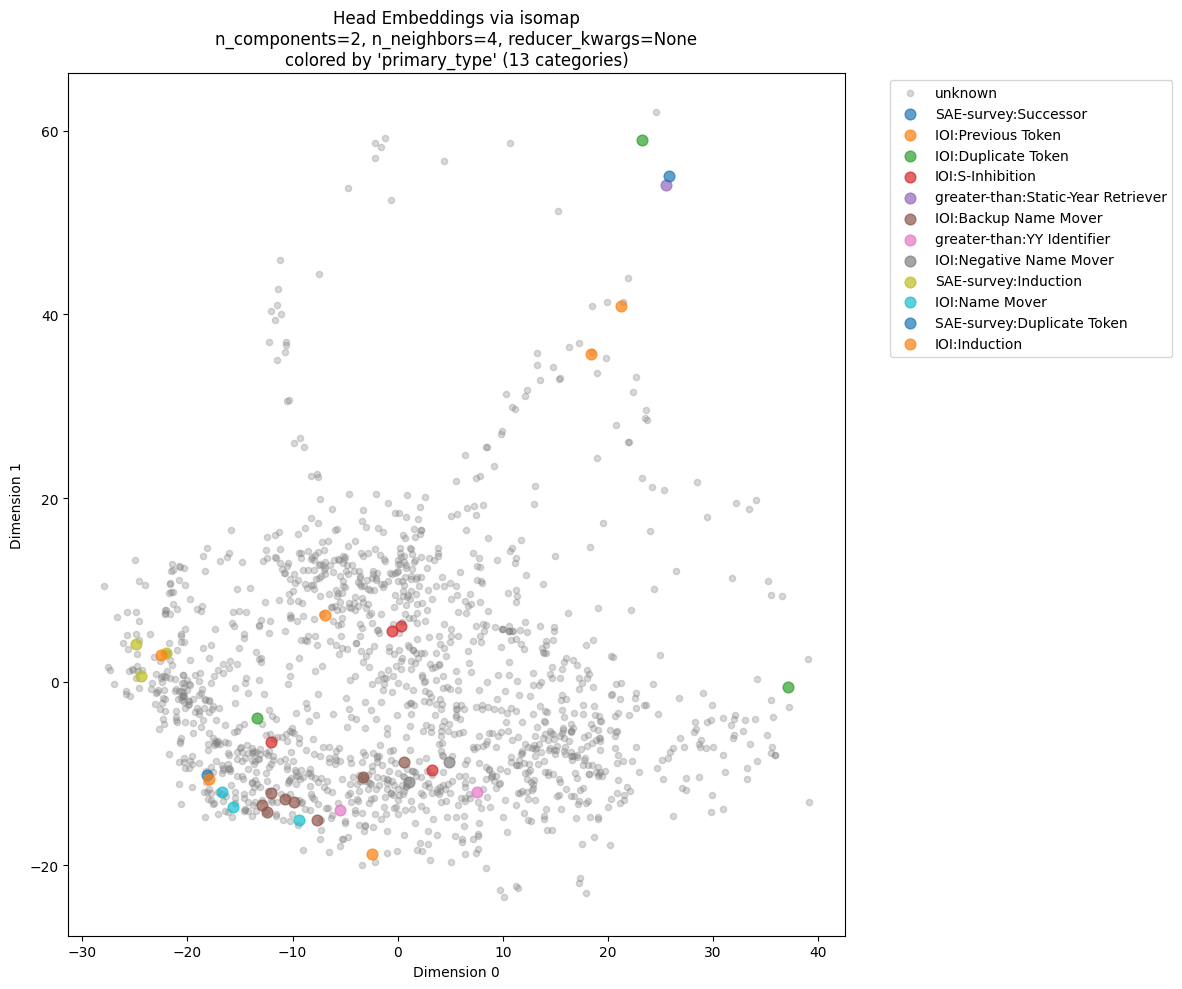

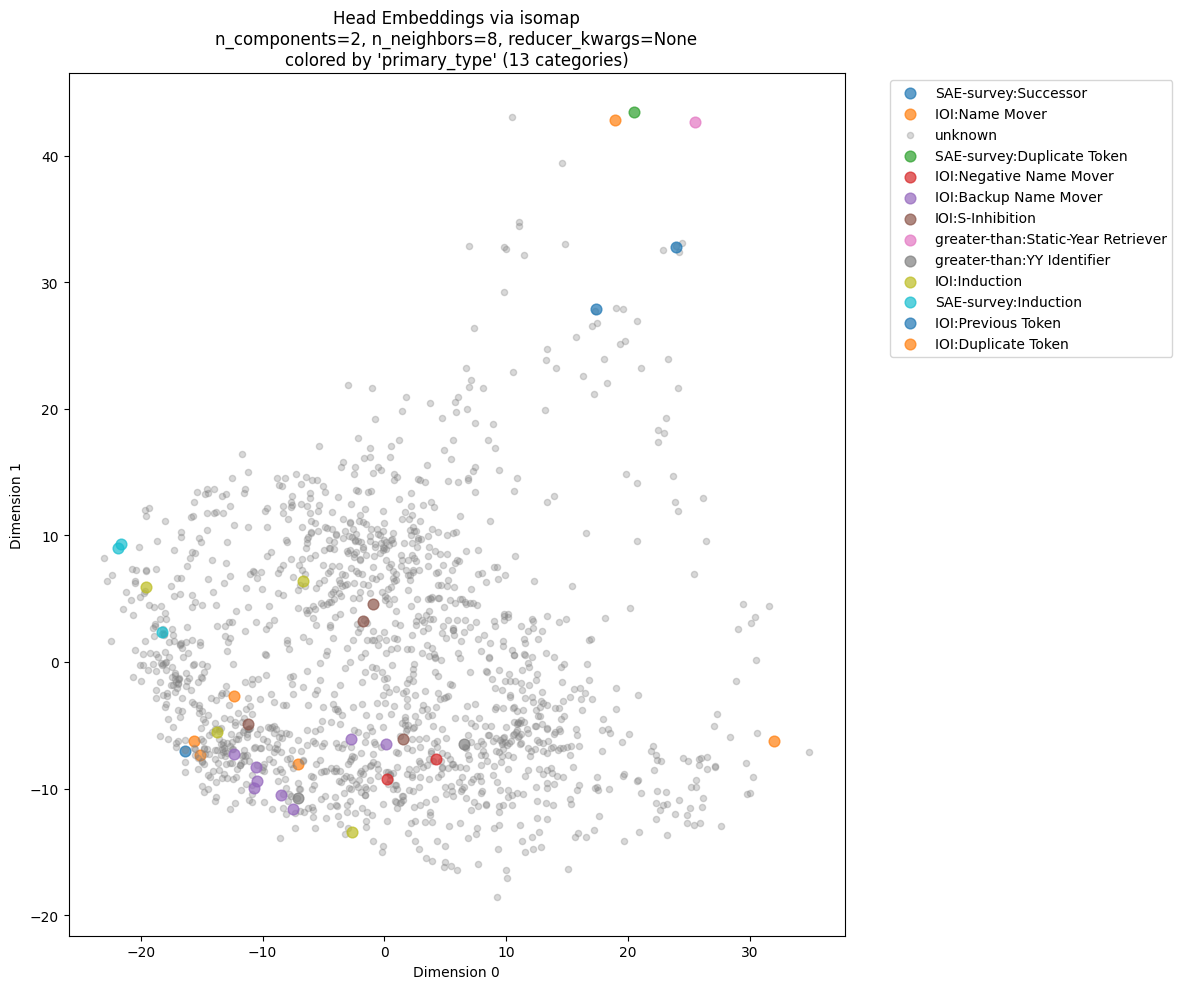

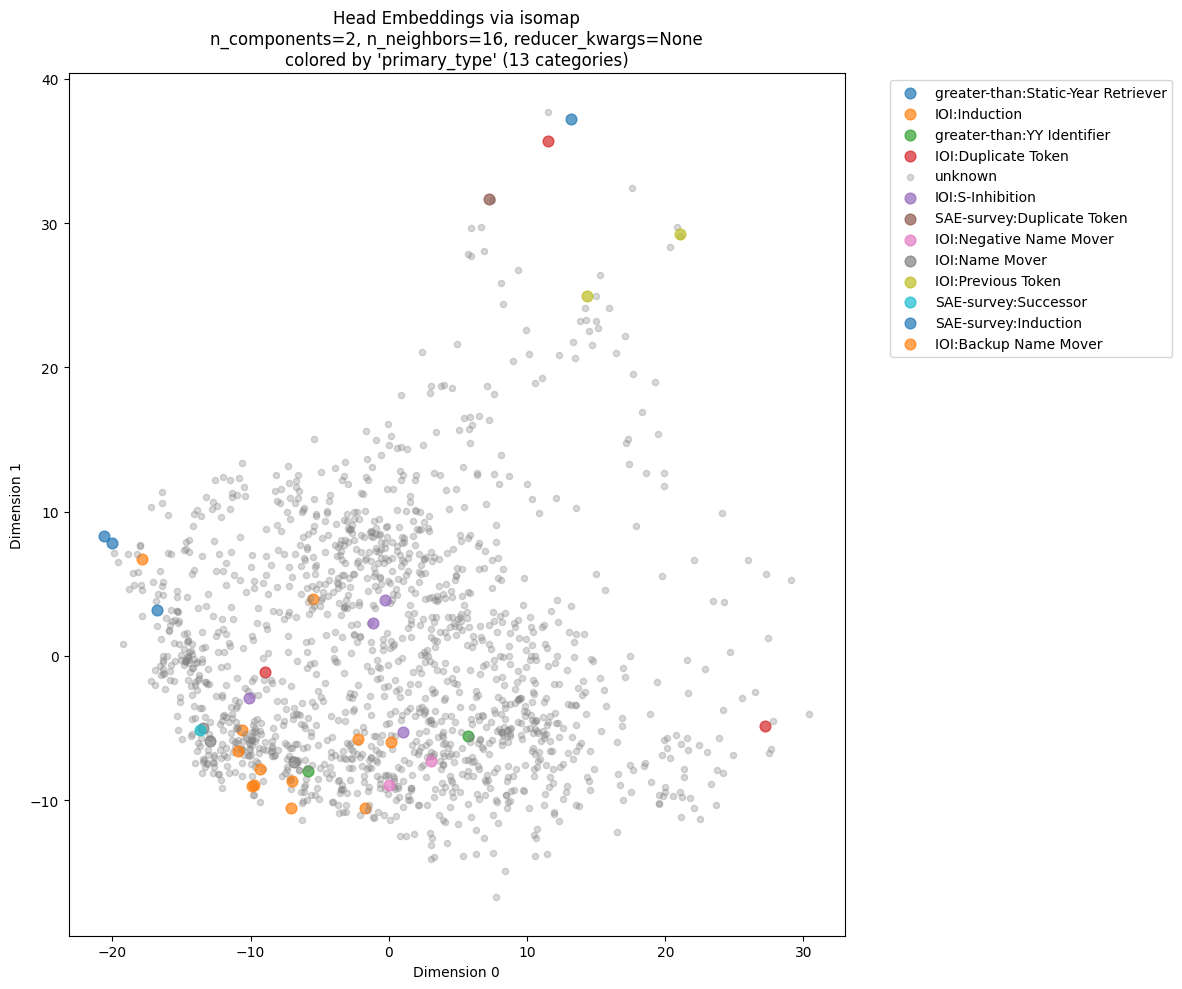

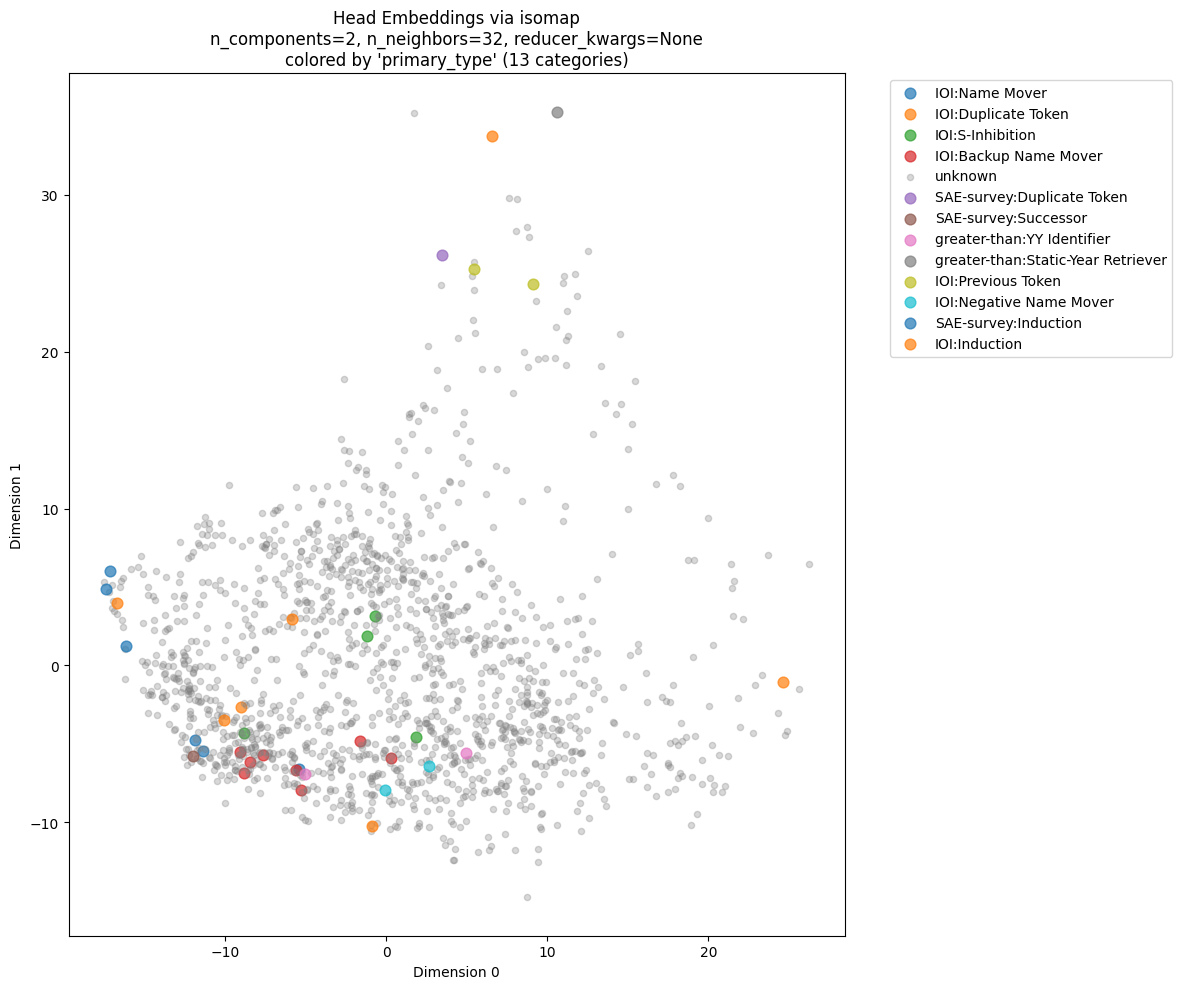

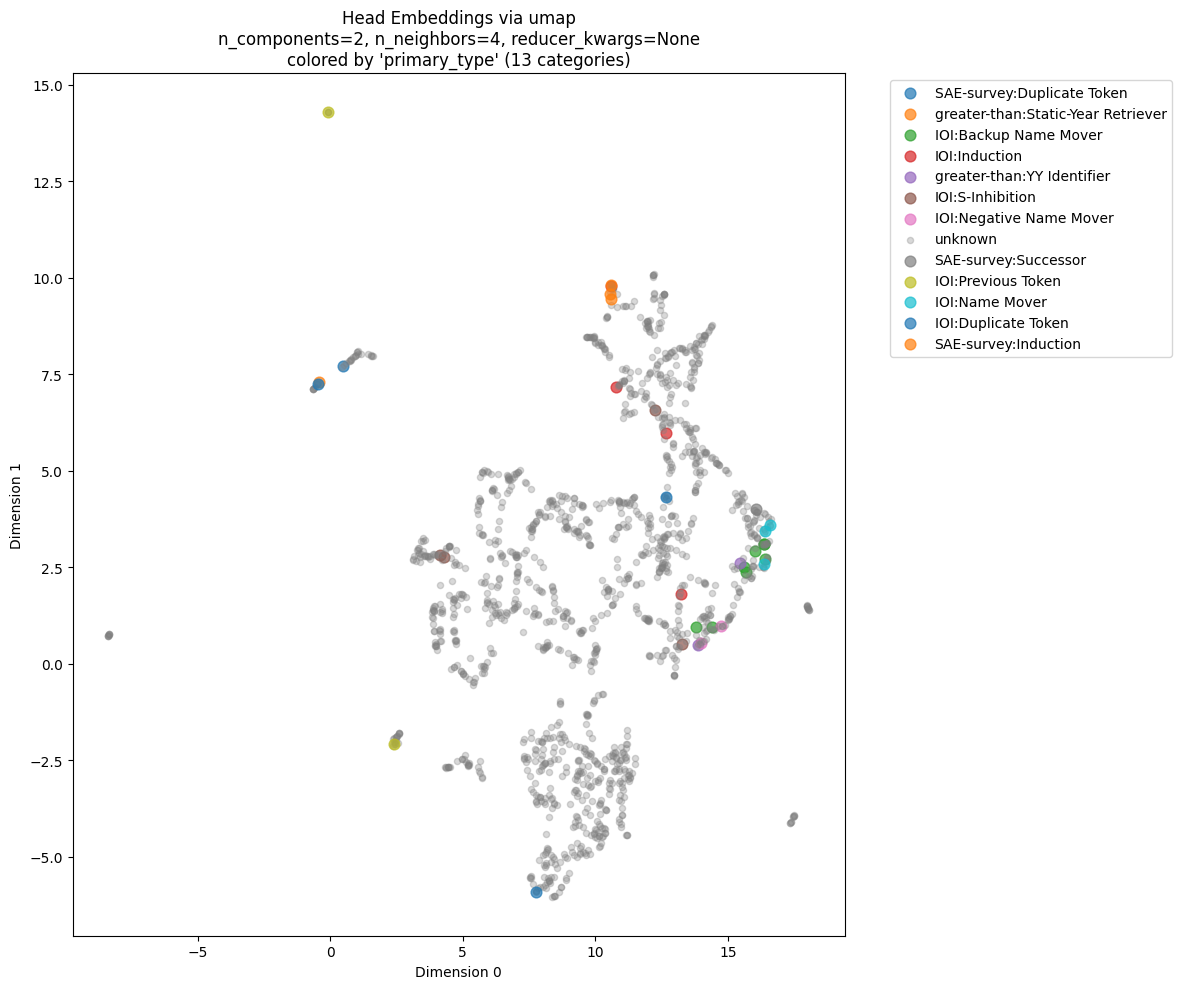

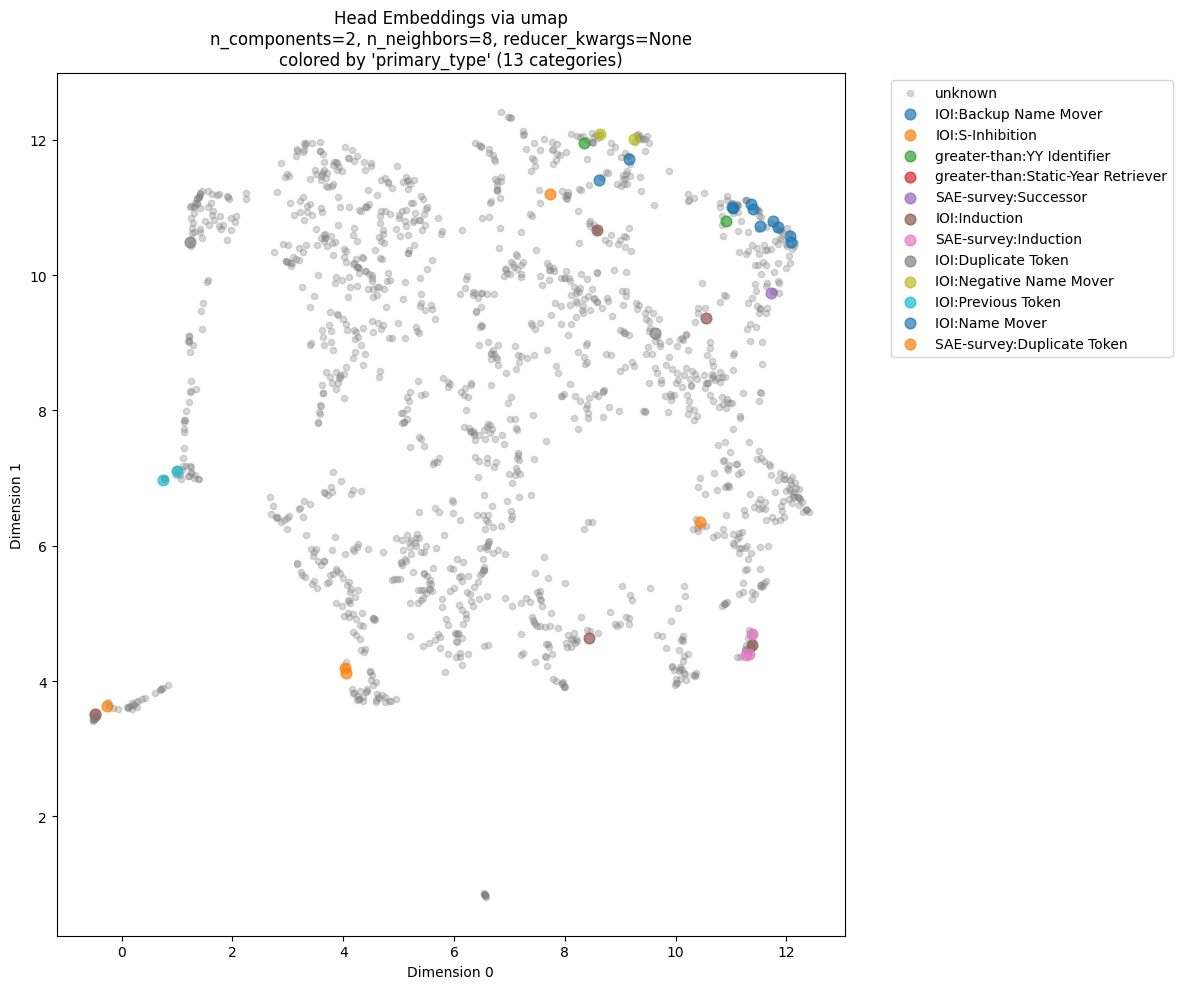

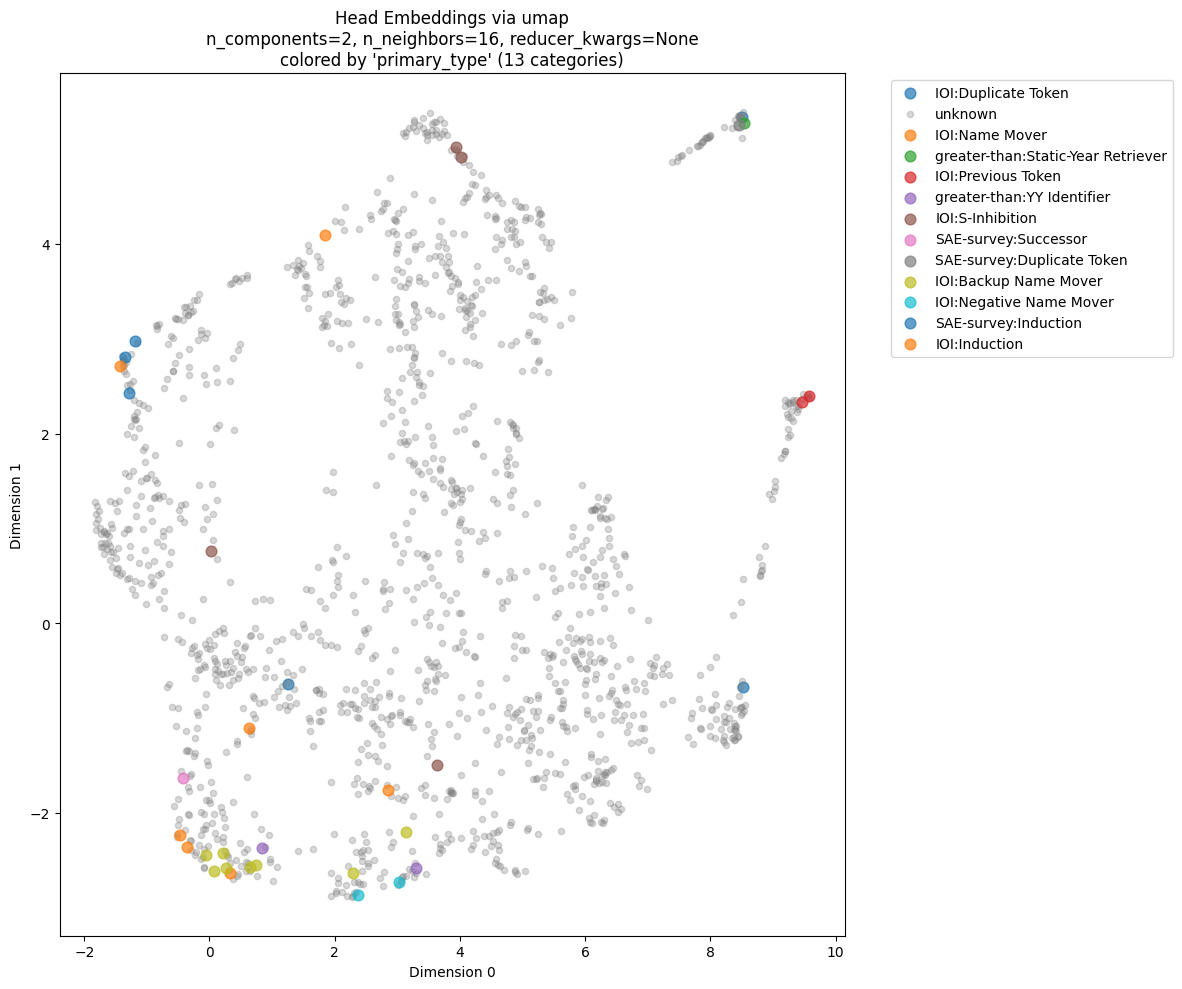

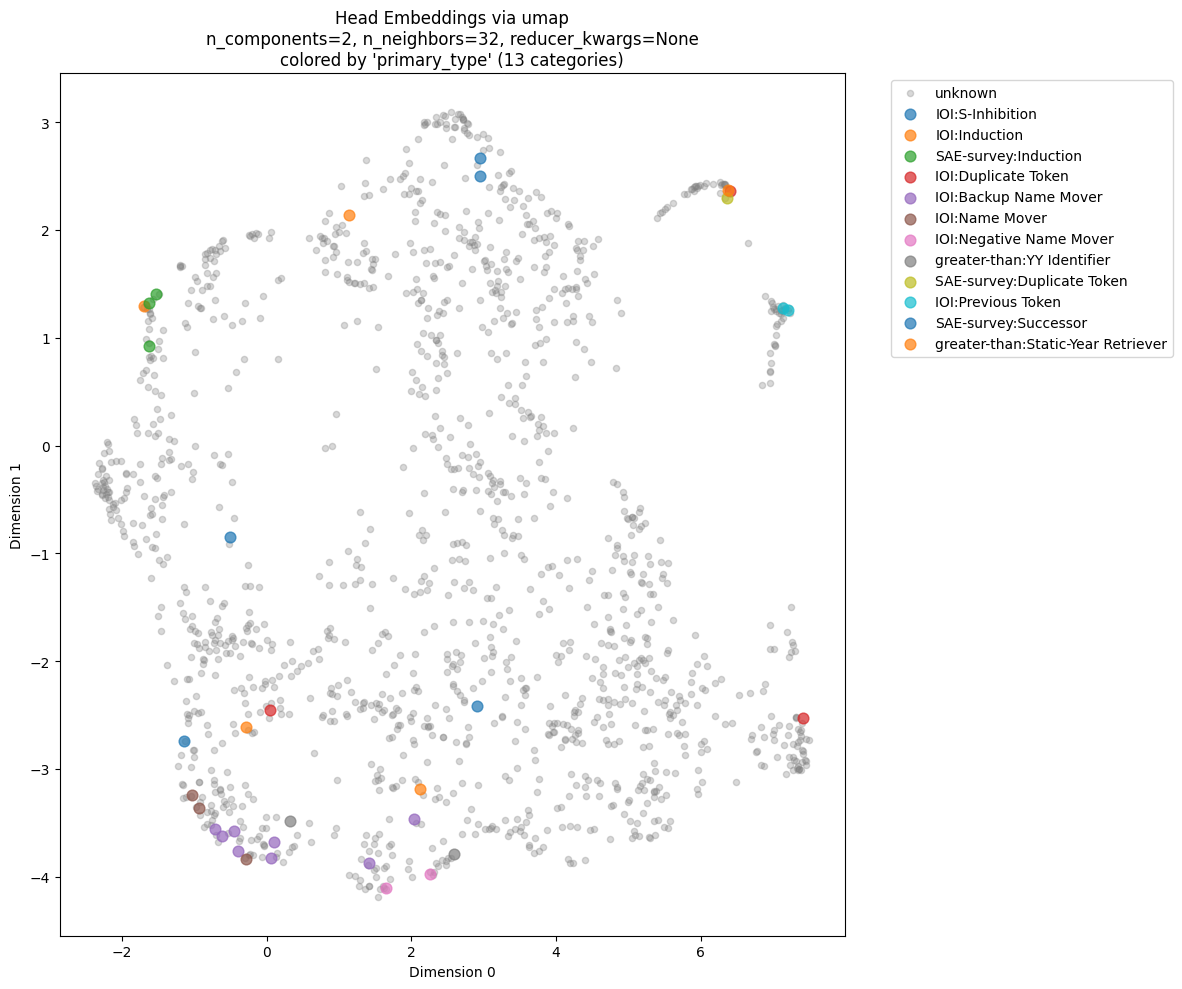

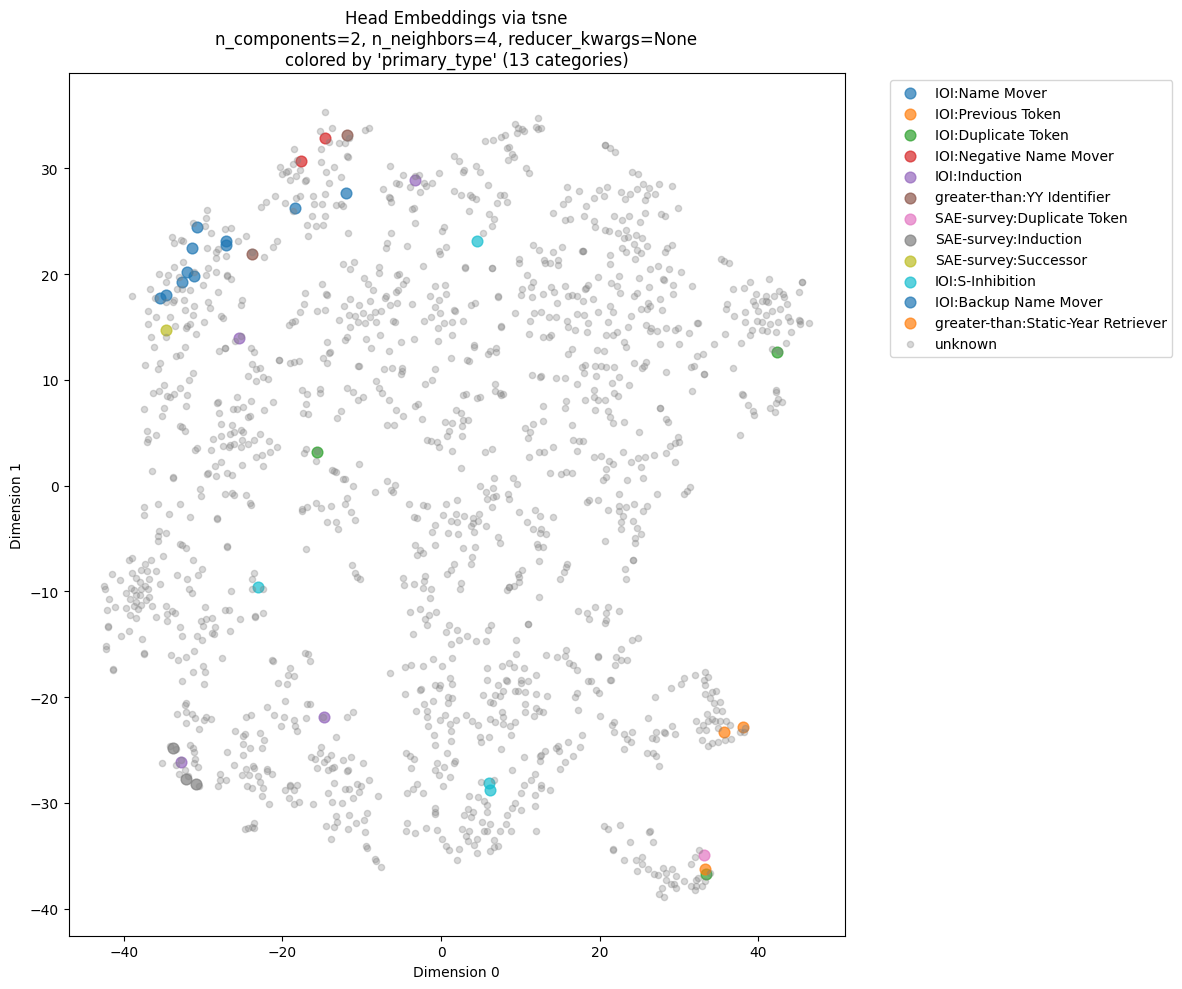

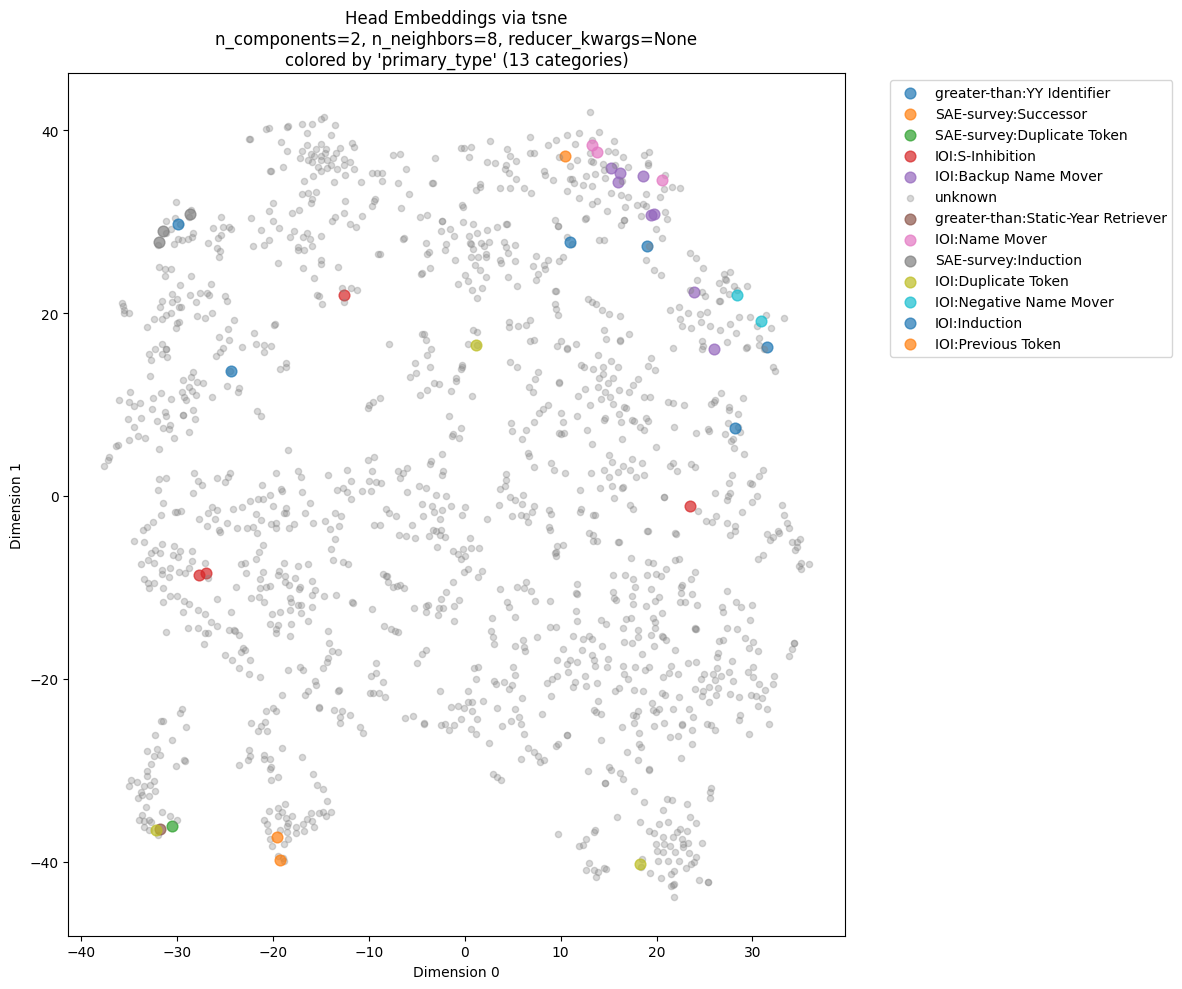

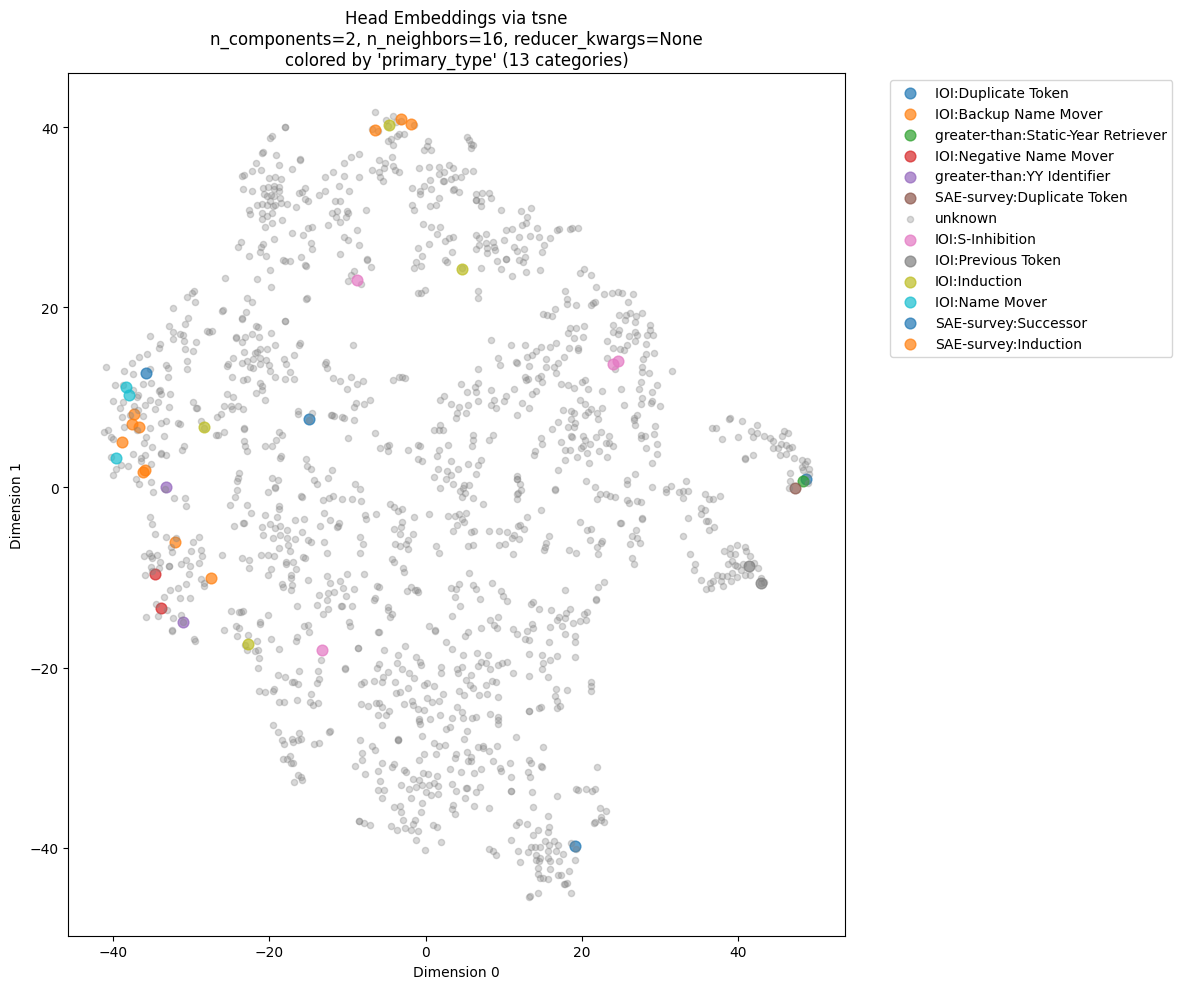

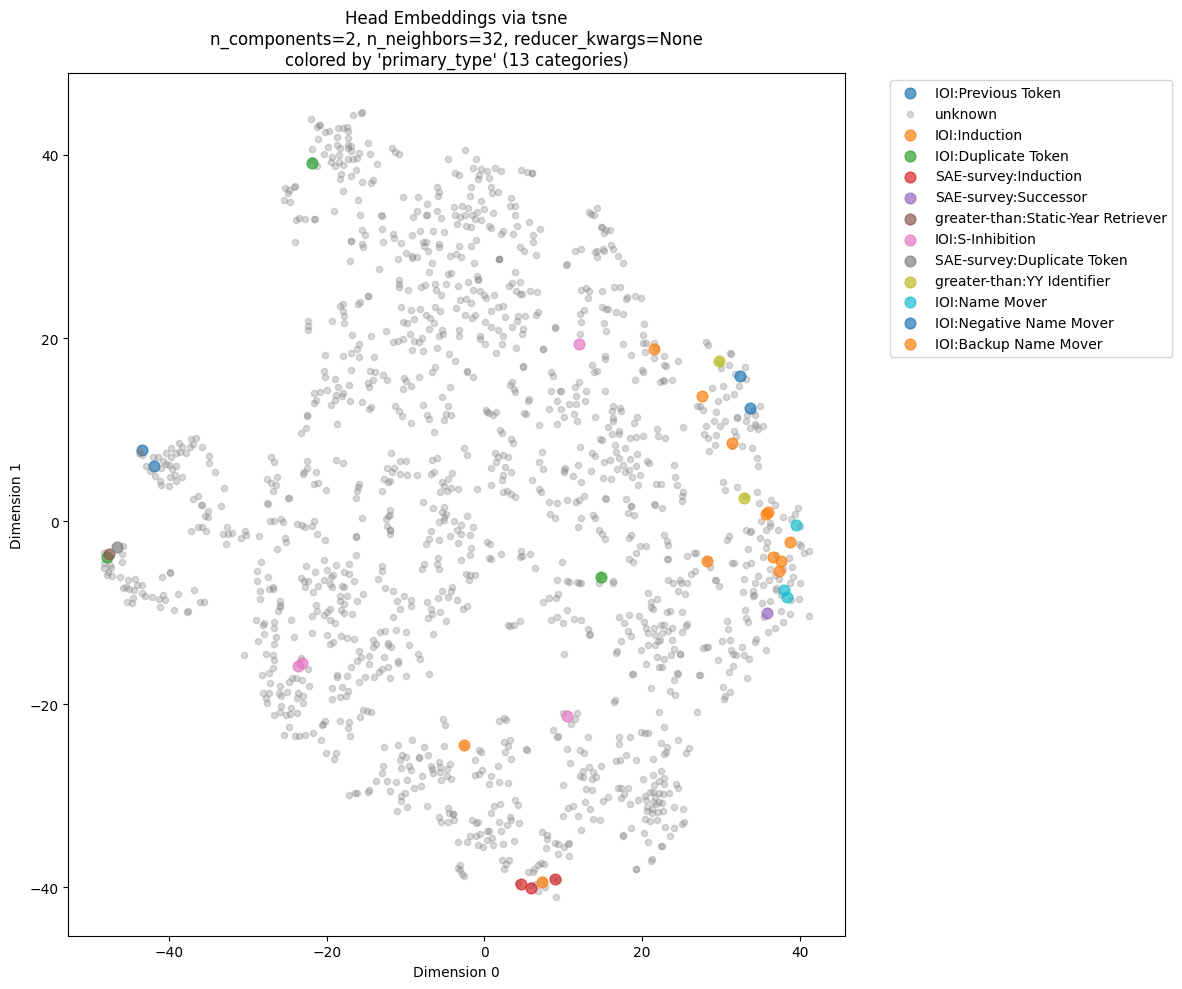

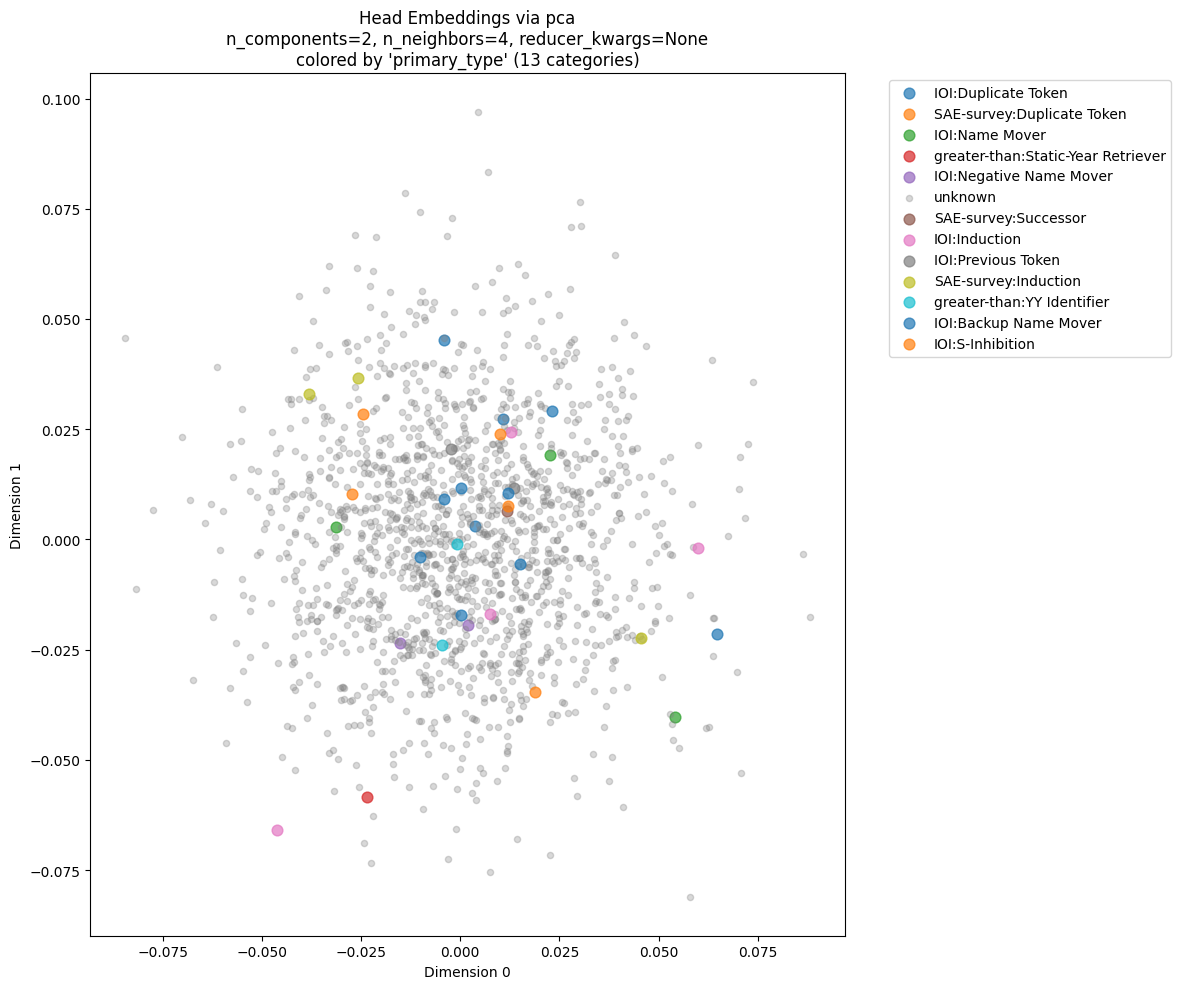

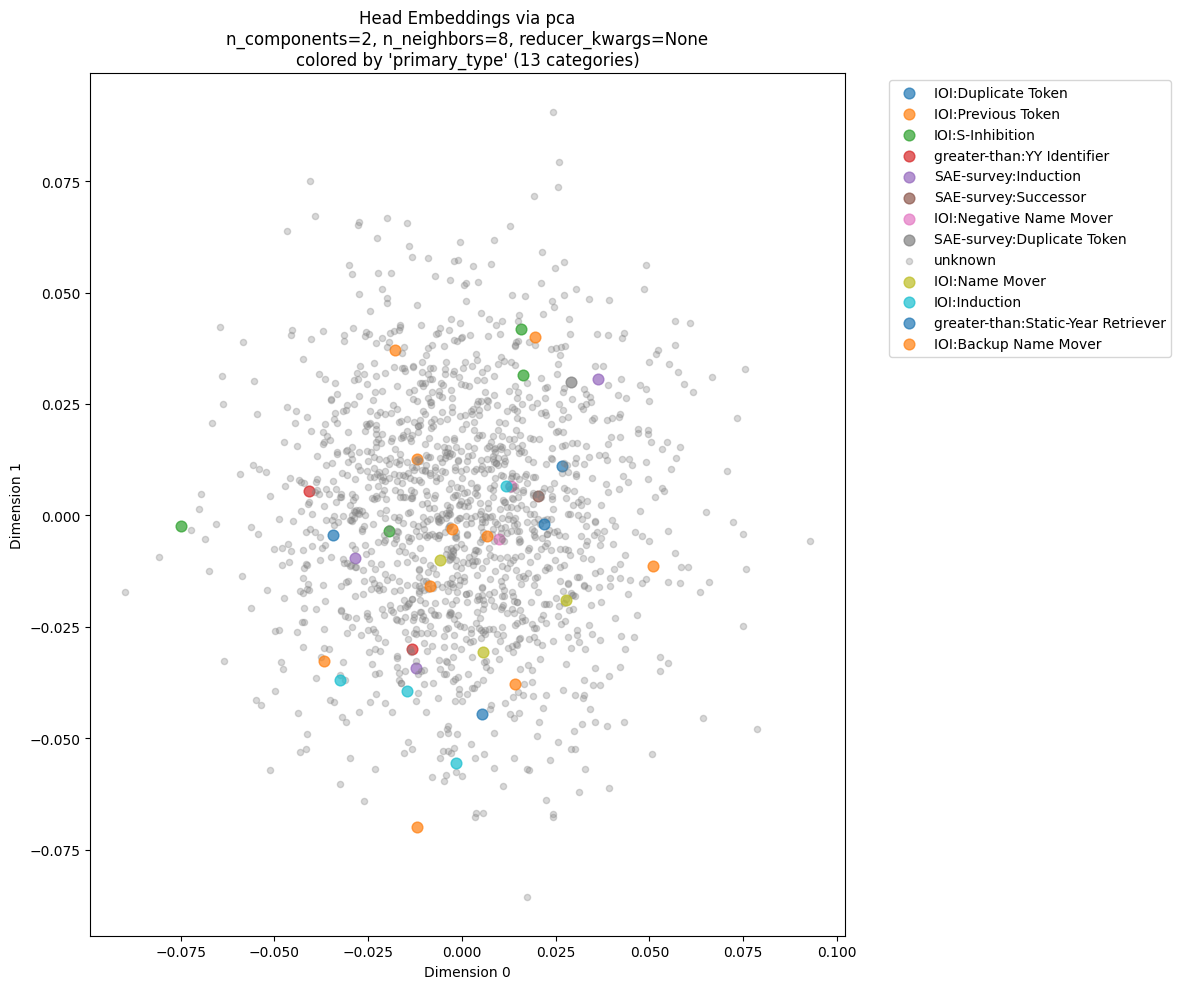

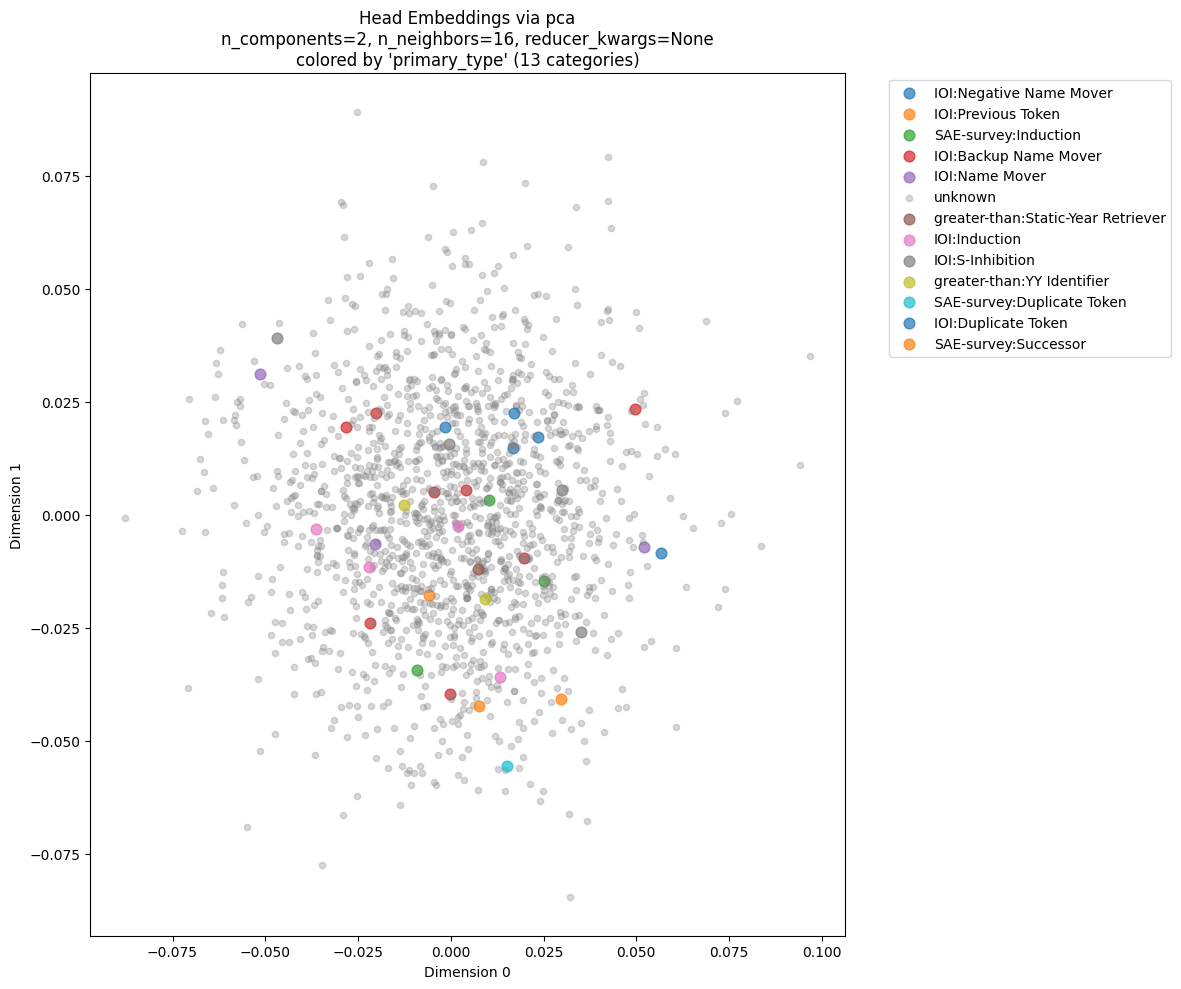

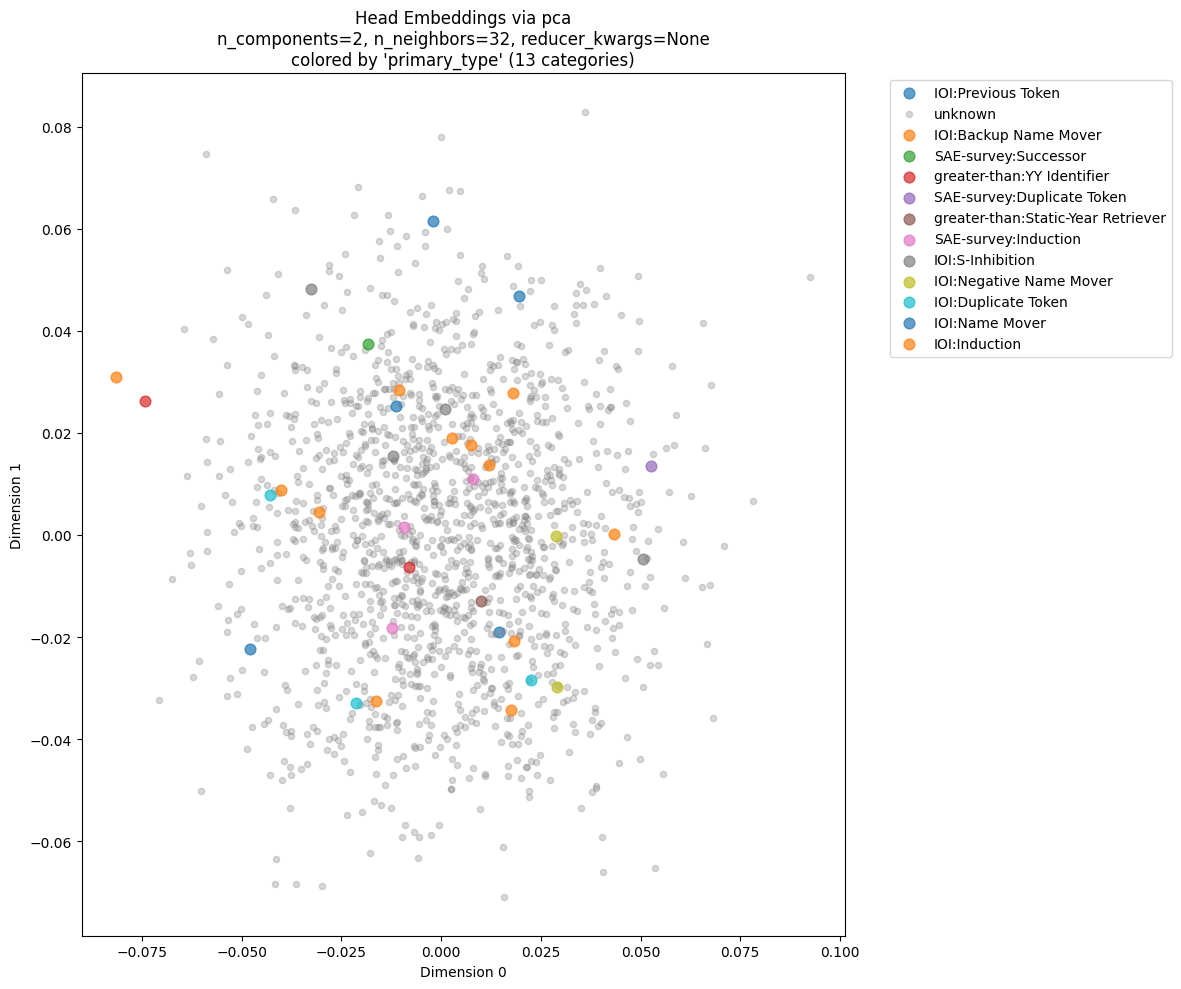

In [27]:
def plot_head_embeddings(
	df: pl.DataFrame,
	color_by: str = "primary_type",
	dims: tuple[int, int] = (0, 1),
	alphas: tuple[float, float] = (0.7, 0.3),
	sizes: tuple[int, int] = (60, 20),
	unknown_color: str = "gray",
):
	"""Plot head embeddings colored by the specified column"""
	fig: plt.Figure
	ax: plt.Axes
	fig, ax = plt.subplots(figsize=(12, 10))

	# Get unique values for color assignment
	categories: list = df[color_by].unique().to_list()
	cmap: matplotlib.colors.Colormap = plt.cm.get_cmap("tab20", len(categories))
	color_map: dict = {cat: cmap(i) for i, cat in enumerate(categories)}

	# Extract embedding dimensions
	x_col: str = f"embed.{dims[0]}"
	y_col: str = f"embed.{dims[1]}"

	# Create scatter plot
	for cat in categories:
		cat_df: pl.DataFrame = df.filter(pl.col(color_by) == cat)
		scatter_kwargs: dict = dict(
			alpha=alphas[0] if cat != "unknown" else alphas[1],
			s=sizes[0] if cat != "unknown" else sizes[1],
		)
		if cat == "unknown":
			scatter_kwargs["color"] = unknown_color
		ax.scatter(
			cat_df[x_col],
			cat_df[y_col],
			label=cat,
			**scatter_kwargs,
		)

	ax.set_xlabel(f"Dimension {dims[0]}")
	ax.set_ylabel(f"Dimension {dims[1]}")
	title: str = (
		f"Head Embeddings via {df._embed_meta['embedding_method']}\n"
		f"n_components={df._embed_meta['n_components']}, n_neighbors={df._embed_meta['n_neighbors']}, reducer_kwargs={df._embed_meta['reducer_kwargs']}\n"
		f"colored by '{color_by}' ({len(categories)} categories)"
	)
	ax.set_title(title)

	# Add legend (potentially outside plot for many categories)
	if len(categories) > 10:
		ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
	else:
		ax.legend()

	plt.tight_layout()
	return fig, ax


for df in HEAD_EMBED_DFS:
	plot_head_embeddings(df, color_by="primary_type", dims=(0, 1))